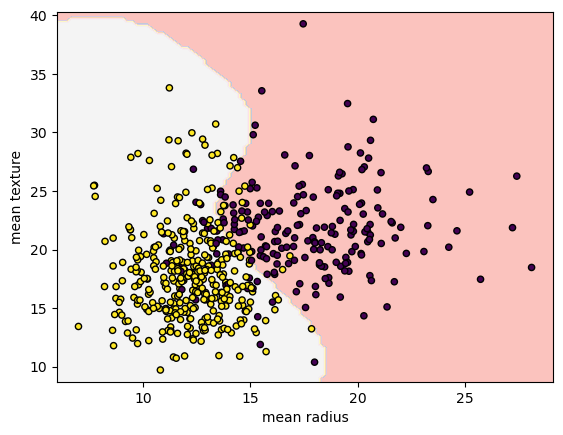

In [3]:
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC

cancer = load_breast_cancer()
X = cancer.data[:, :2]
y = cancer.target

svm = SVC(kernel="rbf", C=1)
svm.fit(X, y)

DecisionBoundaryDisplay.from_estimator(
        svm,
        X,
        response_method="predict",
        alpha=0.8,
        cmap="Pastel1",
        xlabel=cancer.feature_names[0],
        ylabel=cancer.feature_names[1],
    )

plt.scatter(X[:, 0], X[:, 1], 
            c=y, 
            s=20, edgecolors="k")
plt.show()

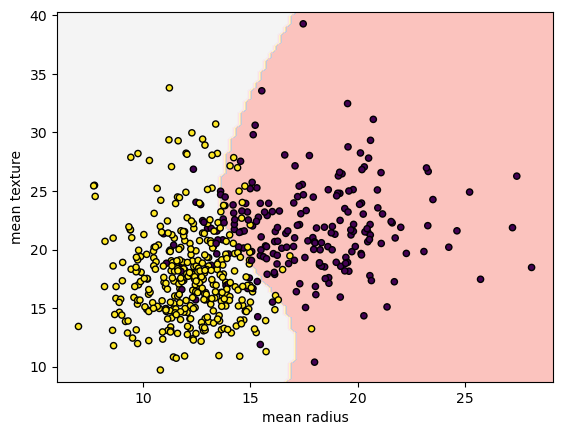

In [4]:
svm = SVC(kernel="poly", C=1)
svm.fit(X, y)

DecisionBoundaryDisplay.from_estimator(
        svm,
        X,
        response_method="predict",
        alpha=0.8,
        cmap="Pastel1",
        xlabel=cancer.feature_names[0],
        ylabel=cancer.feature_names[1],
    )

plt.scatter(X[:, 0], X[:, 1], 
            c=y, 
            s=20, edgecolors="k")
plt.show()

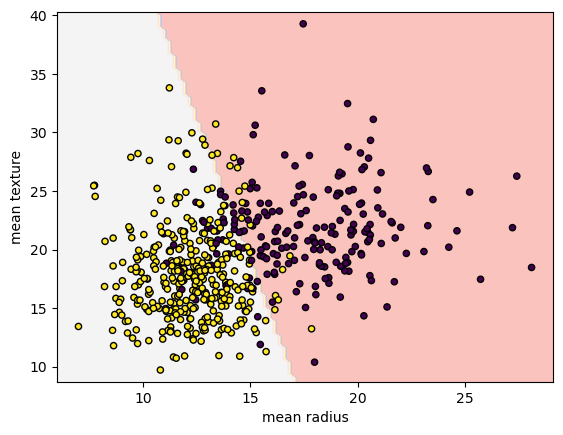

In [5]:
svm = SVC(kernel="linear", C=1)
svm.fit(X, y)

DecisionBoundaryDisplay.from_estimator(
        svm,
        X,
        response_method="predict",
        alpha=0.8,
        cmap="Pastel1",
        xlabel=cancer.feature_names[0],
        ylabel=cancer.feature_names[1],
    )

plt.scatter(X[:, 0], X[:, 1], 
            c=y, 
            s=20, edgecolors="k")
plt.show()

In [6]:
import pandas as pd

In [7]:
data = pd.read_csv("heart_failure_clinical_records_dataset.csv")

data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


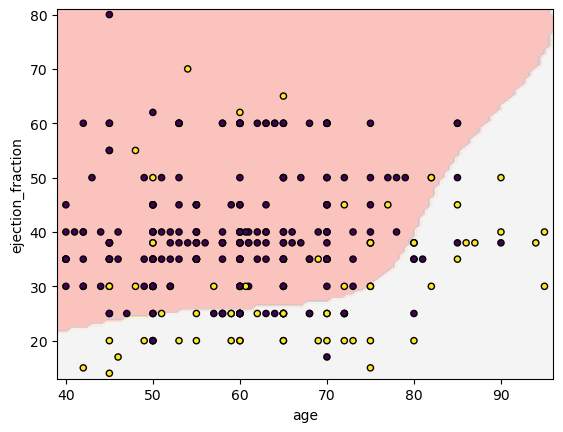

In [18]:
from sklearn.model_selection import train_test_split
X = data[["age", "ejection_fraction"]]
y = data["DEATH_EVENT"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
svm = SVC(kernel="rbf", C=1)
svm.fit(X, y)

DecisionBoundaryDisplay.from_estimator(
    svm,
    X,
    response_method="predict",
    alpha=0.8,
    cmap="Pastel1",
    xlabel=X.columns[0],
    ylabel=X.columns[1],
)

plt.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=y,
    s=20,
    edgecolors="k"
)

plt.show()

In [28]:
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
results = []

def evaluate_model(name, model):

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f"\n{name}")
    print("="*50)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    return model



Logistic Regression
Accuracy: 0.7
Precision: 0.8888888888888888
Recall: 0.32
F1 Score: 0.47058823529411764

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.97      0.79        35
           1       0.89      0.32      0.47        25

    accuracy                           0.70        60
   macro avg       0.78      0.65      0.63        60
weighted avg       0.76      0.70      0.66        60



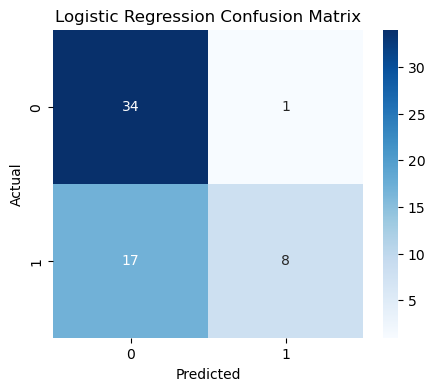

In [29]:
# Logistic Regression

lr_model = evaluate_model(
    'Logistic Regression',
    LogisticRegression()
)



Decision Tree
Accuracy: 0.7
Precision: 0.7692307692307693
Recall: 0.4
F1 Score: 0.5263157894736842

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.91      0.78        35
           1       0.77      0.40      0.53        25

    accuracy                           0.70        60
   macro avg       0.73      0.66      0.65        60
weighted avg       0.72      0.70      0.67        60



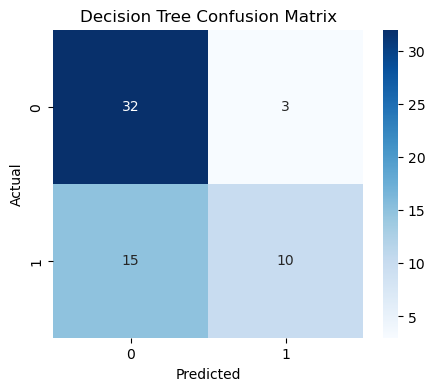

In [30]:
# Decision Tree

dt_model = evaluate_model(
    'Decision Tree',
    DecisionTreeClassifier(random_state=42)
)



Random Forest
Accuracy: 0.7333333333333333
Precision: 0.8
Recall: 0.48
F1 Score: 0.6

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.91      0.80        35
           1       0.80      0.48      0.60        25

    accuracy                           0.73        60
   macro avg       0.76      0.70      0.70        60
weighted avg       0.75      0.73      0.72        60



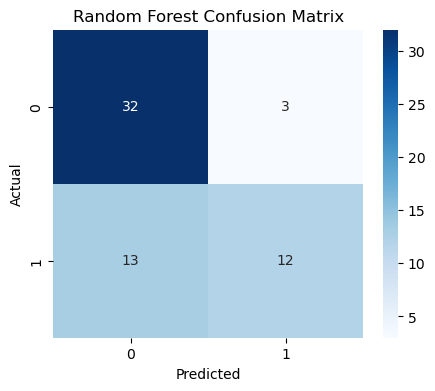

In [31]:
# Random Forest

rf_model = evaluate_model(
    'Random Forest',
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
)



KNN
Accuracy: 0.6833333333333333
Precision: 0.8
Recall: 0.32
F1 Score: 0.45714285714285713

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.94      0.78        35
           1       0.80      0.32      0.46        25

    accuracy                           0.68        60
   macro avg       0.73      0.63      0.62        60
weighted avg       0.72      0.68      0.64        60



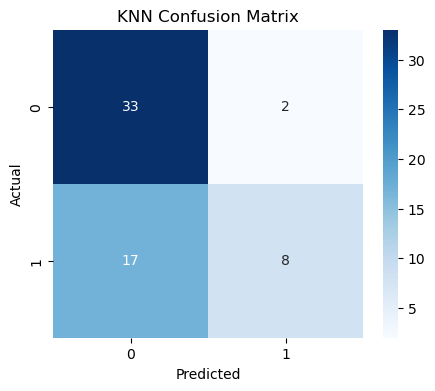

In [32]:
# KNN

knn_model = evaluate_model(
    'KNN',
    KNeighborsClassifier(n_neighbors=5)
)
